c:\Users\Alicja\Desktop\kurs-datascience\Projects\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:44:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Alicja\Desktop\kurs-datascience\Projects\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:44:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Alicja\Desktop\kurs-datascience\Projects\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:44:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Alicja\Desktop\kurs-datascience\Projects\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:44:42] WARNING: C:\a


=== TABELA METRYK I CZASÓW ===
            Model  ROC AUC (CV)  Łączny czas treningu (s)
    Random Forest        0.9153                    7.2138
Gradient Boosting        0.9012                    6.8458
          XGBoost        0.9037                   11.6347


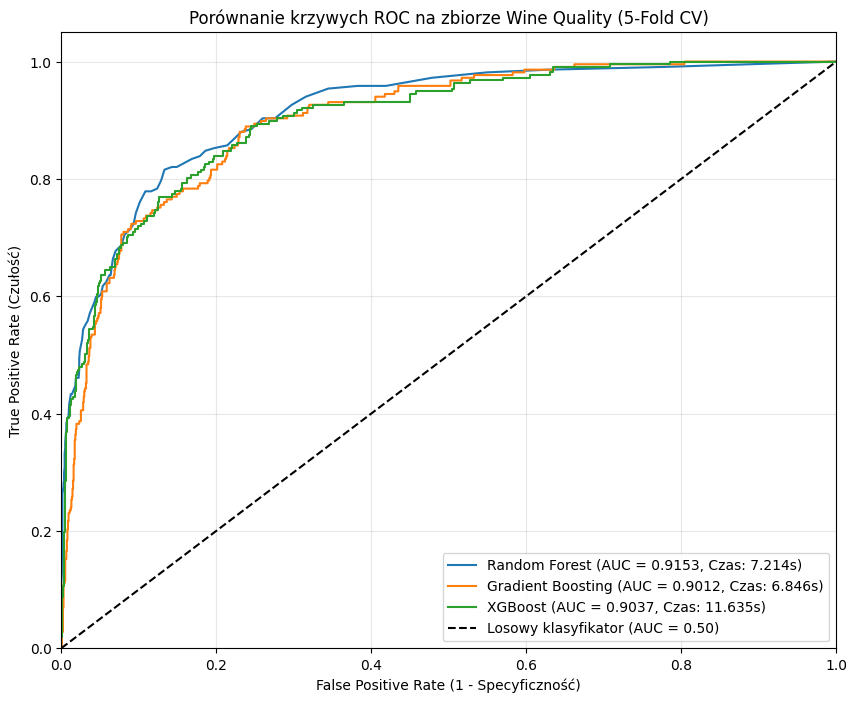

In [1]:
# Porownaj Random Forest, Gradient Boosting i XGBoost na datasecie Wine Quality.
# Dataset:
# https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-
# red.csv
# Wymagania:
# Wczytaj dane, uzyj 'quality' jako target (binaryzacja: quality >= 7 = "good", < 7 = "not
# good")
# Porownaj 3 modele z walidacja krzyzowa
# Narysuj krzywe ROC na jednym wykresie
# Zmierz czas treningu kazdego modelu
# Oczekiwany wynik:
# Krzywe ROC, tabela metryk i czasow

import time
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import auc, roc_curve
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

# Wczytywanie danych url
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# Dane są rozdzielane średnikami
df = pd.read_csv(url, sep=";")

# Wczytanie danych - target
df["target"] = (df["quality"] >= 7).astype(int)

X = df.drop(columns=["quality", "target"])
y = df["target"]

# Definicja modelu 
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42, eval_metric="logloss", use_label_encoder=False
    ),
}
# Przygotowanie struktur na wyniki
results = []
plt.figure(figsize=(10, 8))

# Używamy StratifiedKFold, ponieważ klasy są niezbalansowane
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ewaluacja modeli (Cross-validation)

for name, model in models.items():
    start_time = time.time()

    # Tabele na zmergowane out-of-fold predictions do rysowania krzywej ROC
    # (Alternatywnie można uśredniać krzywe z każdego folda,
    #  ale połączenie prawdopodobieństw daje stabilną globalną krzywą ROC dla CV)
    oof_preds = pd.Series(index=y.index, dtype=float)
    total_train_time = 0

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Pomiar czasu samego trenowania na foldzie
        fold_start = time.time()
        model.fit(X_train, y_train)
        total_train_time += time.time() - fold_start

        # Predykcja prawdopodobieństw dla klasy 1
        oof_preds.iloc[val_idx] = model.predict_proba(X_val)[:, 1]

    # Obliczanie metryk globalnych z Cross-Validation
    fpr, tpr, _ = roc_curve(y, oof_preds)
    roc_auc = auc(fpr, tpr)

    # Zapisywanie wyników czasowych i jakościowych
    results.append(
        {
            "Model": name,
            "ROC AUC (CV)": round(roc_auc, 4),
            "Łączny czas treningu (s)": round(total_train_time, 4),
        }
    )

    # Rysowanie krzywej ROC dla danego modelu
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.4f}, Czas: {total_train_time:.3f}s)",
    )

# Prezentacja wyników
# Tabela podsumowująca
df_results = pd.DataFrame(results)
print("\n=== TABELA METRYK I CZASÓW ===")
print(df_results.to_string(index=False))

# Wykończenie wykresu ROC
plt.plot([0, 1], [0, 1], "k--", label="Losowy klasyfikator (AUC = 0.50)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specyficzność)")
plt.ylabel("True Positive Rate (Czułość)")
plt.title("Porównanie krzywych ROC na zbiorze Wine Quality (5-Fold CV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Przeprowadz tuning hiperparametrow Random Forest na Breast Cancer.
# Wymagania:
# Uzyj RandomizedSearchCV z n_iter=30
# Przestrzen parametrow: n_estimators (50-300), max_depth (3-20), min_samples_split
# (2-20), min_samples_leaf (1-10)
# Porownaj domyslny RF vs zoptymalizowany RF
# Wyswietl najlepsze parametry
# Oczekiwany wynik:
# Porownanie accuracy: domyslny vs zoptymalizowany

import time
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# Wczytanie danych 
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Definicja parametrów
param_dist_rf = {
    "n_estimators": np.arange(50, 301, 10),
    "max_depth": np.arange(3, 21),
    "min_samples_split": np.arange(2, 21),
    "min_samples_leaf": np.arange(1, 11),
}
# Tuning
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=500,  # Wymóg: 30 kombinacji
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
)

start = time.time()
random_search_rf.fit(X_train_c, y_train_c)
elapsed = time.time() - start
# Pobranie najlepszego modelu
best_rf = random_search_rf.best_estimator_

# Trening modelu domyślnego do porównania

default_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
default_rf.fit(X_train_c, y_train_c)

# 5. Predykcja i ewaluacja (Test Accuracy)
y_pred_default = default_rf.predict(X_test_c)
acc_default = accuracy_score(y_test_c, y_pred_default)

y_pred_best = best_rf.predict(X_test_c)
acc_best = accuracy_score(y_test_c, y_pred_best)

# 6. Prezentacja wyników
print("WYNIKI TUNINGU")
print(f"Czas tuningu (30 iteracji * 5-fold CV): {elapsed:.2f}s")
print(f"Najlepsze parametry: {random_search_rf.best_params_}\n")

print("PORÓWNANIE ACCURACY NA ZBIORZE TESTOWYM")
print(f"Domyślny Random Forest:       {acc_default:.4f}")
print(f"Zoptymalizowany Random Forest: {acc_best:.4f}")
print(f"Różnica (Zysk z tuningu):      {(acc_best - acc_default)*100:+.2f}%\n")

print("RAPORT KLASYFIKACJI DLA NAJLEPSZEGO MODELU")
print(classification_report(y_test_c, y_pred_best, target_names=cancer.target_names))